In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/agneaybnair/wine-red/winequality-red.csv


In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## LOAD DATASET

In [18]:
df = pd.read_csv("/kaggle/input/datasets/agneaybnair/wine-red/winequality-red.csv")

# Separate features and target
X = df.drop(columns=["quality"])

print("Original Feature Count:", X.shape[1])
print("Features:")
print(X.columns.tolist())

Original Feature Count: 11
Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


##  CORRELATION MATRIX

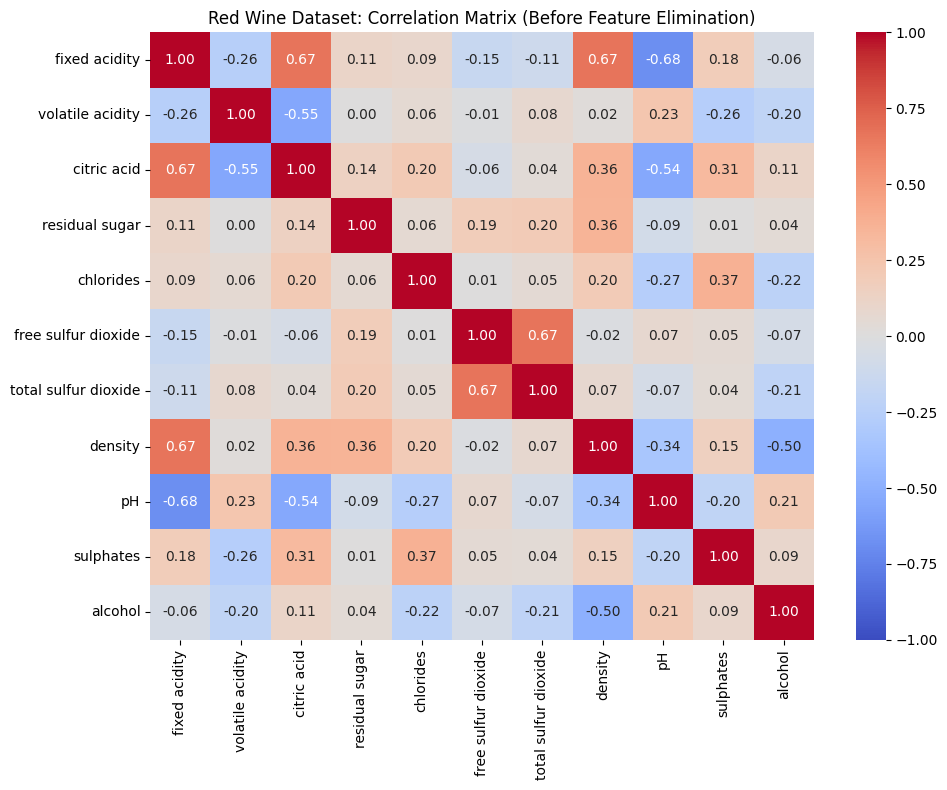

In [19]:
correlation_matrix = X.corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)
plt.title("Red Wine Dataset: Correlation Matrix (Before Feature Elimination)")
plt.tight_layout()
plt.show()

## FEATURE ELIMINATION

In [20]:
def eliminate_highly_correlated_features(data, threshold=0.85):
    """
    Removes highly correlated features using the lower triangle
    of the correlation matrix.
    """
    corr_matrix = data.corr()

    columns_to_drop = set()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                columns_to_drop.add(colname)

    return list(columns_to_drop)

In [21]:

# Execute elimination
features_to_remove = eliminate_highly_correlated_features(
    X,
    threshold=0.85
)

print("\nFeatures flagged for removal:")
print(features_to_remove)

# Remove selected features
X_clean = X.drop(columns=features_to_remove)

print("\nOriginal Feature Count:", X.shape[1])
print("Remaining Feature Count:", X_clean.shape[1])
print("Remaining Features:")
print(X_clean.columns.tolist())


Features flagged for removal:
[]

Original Feature Count: 11
Remaining Feature Count: 11
Remaining Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## CORRELATION MATRIX AFTER ELIMINATION

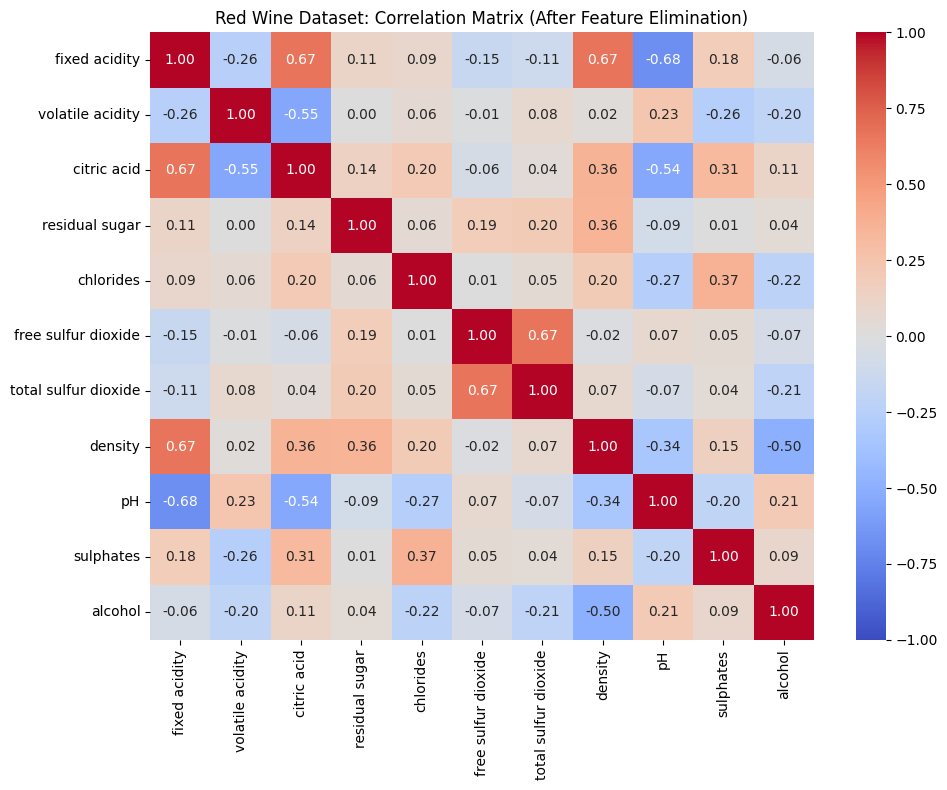

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(
    X_clean.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)
plt.title("Red Wine Dataset: Correlation Matrix (After Feature Elimination)")
plt.tight_layout()
plt.show()